In [10]:
import scipy.io as scio
import numpy as np

mat_path = "./MI1/1.mat"   # 改成你的文件路径

data = scio.loadmat(mat_path)

print("Keys:", [k for k in data.keys() if not k.startswith("__")])
print("-"*40)

for k, v in data.items():
    if k.startswith("__"):
        continue
    print(f"{k}: shape={getattr(v, 'shape', None)}, dtype={getattr(v, 'dtype', type(v))}")
    
    if isinstance(v, np.ndarray) and v.ndim == 1:
        print("   unique:", np.unique(v)[:10])
        print("X:", data["X"].shape)
        print("y classes:", np.unique(data["y"]))
        print("sessions:", np.unique(data["session"]))
        print("groups:", np.unique(data["group"]))

Keys: ['X', 'y', 'session', 'run', 'group']
----------------------------------------
X: shape=(45, 64, 257), dtype=float32
y: shape=(1, 45), dtype=int64
session: shape=(1, 45), dtype=object
run: shape=(1, 45), dtype=object
group: shape=(1, 45), dtype=int64


In [11]:
for k in ["y", "group", "session", "run"]:
    if k in data:
        v = data[k]
        print(f"\n===== {k} =====")
        print("raw shape:", v.shape)
        print(v)


===== y =====
raw shape: (1, 45)
[[1 0 0 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 1 0 1 0 1 1 0 0 1 1 0 0 1 0 1 0 0 1
  1 0 0 1 1 0 1 0 1]]

===== group =====
raw shape: (1, 45)
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2
  2 2 2 2 2 2 2 2 2]]

===== session =====
raw shape: (1, 45)
[[array(['0'], dtype='<U1') array(['0'], dtype='<U1')
  array(['0'], dtype='<U1') array(['0'], dtype='<U1')
  array(['0'], dtype='<U1') array(['0'], dtype='<U1')
  array(['0'], dtype='<U1') array(['0'], dtype='<U1')
  array(['0'], dtype='<U1') array(['0'], dtype='<U1')
  array(['0'], dtype='<U1') array(['0'], dtype='<U1')
  array(['0'], dtype='<U1') array(['0'], dtype='<U1')
  array(['0'], dtype='<U1') array(['0'], dtype='<U1')
  array(['0'], dtype='<U1') array(['0'], dtype='<U1')
  array(['0'], dtype='<U1') array(['0'], dtype='<U1')
  array(['0'], dtype='<U1') array(['0'], dtype='<U1')
  array(['0'], dtype='<U1') array(['0'], dtype='<U1')
  array(['0'], dtype='<U1') array(['0'], dtype='

In [12]:
X = data["X"]
print("X shape:", X.shape)
print("X dtype:", X.dtype)

print("X min:", X.min())
print("X max:", X.max())
print("X mean:", X.mean())
print("X std:", X.std())

X shape: (45, 64, 257)
X dtype: float32
X min: -260.67624
X max: 226.87741
X mean: -0.008001869
X std: 23.279749


In [13]:
x0 = X[0]
print("single sample shape:", x0.shape)   # 应该是 (64, 257)
print(x0)

single sample shape: (64, 257)
[[ -9.219038  -14.2330475 -26.160858  ...  32.896576   45.394245
   23.4192   ]
 [-19.700016  -24.30913   -37.93274   ...  41.374672   50.234386
   28.596457 ]
 [-27.275524  -33.5072    -46.499397  ...  37.20835    40.61484
   26.592974 ]
 ...
 [ -9.160966  -21.994642  -23.250051  ...  25.864393   38.738884
   25.104181 ]
 [  5.694347   -3.7391467  -4.7100577 ...  47.900173   46.37099
   13.116479 ]
 [ -7.528095  -11.91374    -9.349211  ...  10.290755   41.922417
   35.441658 ]]


In [14]:
print("Has NaN:", np.isnan(X).any())
print("Has Inf:", np.isinf(X).any())

Has NaN: False
Has Inf: False


In [15]:
y = np.asarray(data["y"]).squeeze()
group = np.asarray(data["group"]).squeeze()

print("y shape:", y.shape)
print("group shape:", group.shape)

print("y unique:", np.unique(y))
print("group unique:", np.unique(group))

y shape: (45,)
group shape: (45,)
y unique: [0 1]
group unique: [0 1 2]


In [16]:
y_vals, y_counts = np.unique(y, return_counts=True)
print("y distribution:")
for v, c in zip(y_vals, y_counts):
    print(f"label {v}: {c}")

y distribution:
label 0: 23
label 1: 22


In [17]:
g_vals, g_counts = np.unique(group, return_counts=True)
print("group distribution:")
for v, c in zip(g_vals, g_counts):
    print(f"group {v}: {c}")

group distribution:
group 0: 15
group 1: 15
group 2: 15


In [18]:
N = X.shape[0]
print("N from X:", N)
print("N from y:", len(y))
print("N from group:", len(group))

N from X: 45
N from y: 45
N from group: 45


In [19]:
X.shape[0] == len(y) == len(group)

True

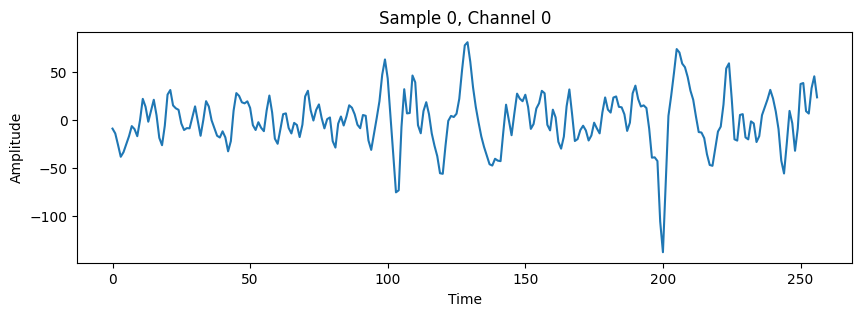

In [20]:
import matplotlib.pyplot as plt

sample_idx = 0
channel_idx = 0

plt.figure(figsize=(10, 3))
plt.plot(X[sample_idx, channel_idx, :])
plt.title(f"Sample {sample_idx}, Channel {channel_idx}")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

In [21]:
session = np.asarray(data["session"]).squeeze()
run = np.asarray(data["run"]).squeeze()

print("session shape:", session.shape)
print("run shape:", run.shape)

print("session first 10:")
for i in range(min(10, len(session))):
    print(i, session[i], type(session[i]))

print("\nrun first 10:")
for i in range(min(10, len(run))):
    print(i, run[i], type(run[i]))

session shape: (45,)
run shape: (45,)
session first 10:
0 ['0'] <class 'numpy.ndarray'>
1 ['0'] <class 'numpy.ndarray'>
2 ['0'] <class 'numpy.ndarray'>
3 ['0'] <class 'numpy.ndarray'>
4 ['0'] <class 'numpy.ndarray'>
5 ['0'] <class 'numpy.ndarray'>
6 ['0'] <class 'numpy.ndarray'>
7 ['0'] <class 'numpy.ndarray'>
8 ['0'] <class 'numpy.ndarray'>
9 ['0'] <class 'numpy.ndarray'>

run first 10:
0 ['0'] <class 'numpy.ndarray'>
1 ['0'] <class 'numpy.ndarray'>
2 ['0'] <class 'numpy.ndarray'>
3 ['0'] <class 'numpy.ndarray'>
4 ['0'] <class 'numpy.ndarray'>
5 ['0'] <class 'numpy.ndarray'>
6 ['0'] <class 'numpy.ndarray'>
7 ['0'] <class 'numpy.ndarray'>
8 ['0'] <class 'numpy.ndarray'>
9 ['0'] <class 'numpy.ndarray'>


In [22]:
def unwrap_obj_array(arr, n=10):
    arr = np.asarray(arr).squeeze()
    for i in range(min(n, len(arr))):
        print(f"idx={i}, value={arr[i]}, type={type(arr[i])}")

unwrap_obj_array(data["session"])
unwrap_obj_array(data["run"])

idx=0, value=['0'], type=<class 'numpy.ndarray'>
idx=1, value=['0'], type=<class 'numpy.ndarray'>
idx=2, value=['0'], type=<class 'numpy.ndarray'>
idx=3, value=['0'], type=<class 'numpy.ndarray'>
idx=4, value=['0'], type=<class 'numpy.ndarray'>
idx=5, value=['0'], type=<class 'numpy.ndarray'>
idx=6, value=['0'], type=<class 'numpy.ndarray'>
idx=7, value=['0'], type=<class 'numpy.ndarray'>
idx=8, value=['0'], type=<class 'numpy.ndarray'>
idx=9, value=['0'], type=<class 'numpy.ndarray'>
idx=0, value=['0'], type=<class 'numpy.ndarray'>
idx=1, value=['0'], type=<class 'numpy.ndarray'>
idx=2, value=['0'], type=<class 'numpy.ndarray'>
idx=3, value=['0'], type=<class 'numpy.ndarray'>
idx=4, value=['0'], type=<class 'numpy.ndarray'>
idx=5, value=['0'], type=<class 'numpy.ndarray'>
idx=6, value=['0'], type=<class 'numpy.ndarray'>
idx=7, value=['0'], type=<class 'numpy.ndarray'>
idx=8, value=['0'], type=<class 'numpy.ndarray'>
idx=9, value=['0'], type=<class 'numpy.ndarray'>


In [23]:
X = data["X"]
y = np.asarray(data["y"]).squeeze()
group = np.asarray(data["group"]).squeeze()

print("=== Final Check ===")
print("X.shape =", X.shape)
print("y.shape =", y.shape, "unique =", np.unique(y))
print("group.shape =", group.shape, "unique =", np.unique(group))
print("NaN in X =", np.isnan(X).any())
print("Inf in X =", np.isinf(X).any())
print("N consistent =", (X.shape[0] == len(y) == len(group)))

=== Final Check ===
X.shape = (45, 64, 257)
y.shape = (45,) unique = [0 1]
group.shape = (45,) unique = [0 1 2]
NaN in X = False
Inf in X = False
N consistent = True


In [24]:
print(np.unique(np.asarray(data["y"]).squeeze(), return_counts=True))
print(np.unique(np.asarray(data["group"]).squeeze(), return_counts=True))
print(np.asarray(data["session"]).squeeze()[:10])
print(np.asarray(data["run"]).squeeze()[:10])

(array([0, 1]), array([23, 22]))
(array([0, 1, 2]), array([15, 15, 15]))
[array(['0'], dtype='<U1') array(['0'], dtype='<U1')
 array(['0'], dtype='<U1') array(['0'], dtype='<U1')
 array(['0'], dtype='<U1') array(['0'], dtype='<U1')
 array(['0'], dtype='<U1') array(['0'], dtype='<U1')
 array(['0'], dtype='<U1') array(['0'], dtype='<U1')]
[array(['0'], dtype='<U1') array(['0'], dtype='<U1')
 array(['0'], dtype='<U1') array(['0'], dtype='<U1')
 array(['0'], dtype='<U1') array(['0'], dtype='<U1')
 array(['0'], dtype='<U1') array(['0'], dtype='<U1')
 array(['0'], dtype='<U1') array(['0'], dtype='<U1')]


In [25]:
print("Trials per subject")

group = np.asarray(data["group"]).squeeze()

for g in np.unique(group):
    print(g, np.sum(group == g))

Trials per subject
0 15
1 15
2 15


In [26]:
print(np.unique(np.asarray(data["y"]).squeeze(), return_counts=True))

print(np.unique(np.asarray(data["group"]).squeeze(), return_counts=True))

print(np.asarray(data["session"]).squeeze()[:10])

(array([0, 1]), array([23, 22]))
(array([0, 1, 2]), array([15, 15, 15]))
[array(['0'], dtype='<U1') array(['0'], dtype='<U1')
 array(['0'], dtype='<U1') array(['0'], dtype='<U1')
 array(['0'], dtype='<U1') array(['0'], dtype='<U1')
 array(['0'], dtype='<U1') array(['0'], dtype='<U1')
 array(['0'], dtype='<U1') array(['0'], dtype='<U1')]


In [27]:
import scipy.io as scio
import numpy as np
import torch
from torch.utils.data import Dataset


class MI_dataset(Dataset):
    def __init__(self, mat_path):
        data = scio.loadmat(mat_path)

        X = data["X"]                       # (N, C, T)
        y_task = np.asarray(data["y"]).squeeze()      # (N,)
        y_user = np.asarray(data["group"]).squeeze()  # (N,)

        # 基本检查
        assert X.ndim == 3, f"X should be 3-D, got shape {X.shape}"
        assert y_task.ndim == 1, f"y_task should be 1-D, got shape {y_task.shape}"
        assert y_user.ndim == 1, f"y_user should be 1-D, got shape {y_user.shape}"
        assert X.shape[0] == len(y_task) == len(y_user), \
            f"Sample count mismatch: X={X.shape[0]}, y_task={len(y_task)}, y_user={len(y_user)}"

        # 转 tensor
        self.x = torch.tensor(X, dtype=torch.float32)
        self.y_task = torch.tensor(y_task, dtype=torch.long)
        self.y_user = torch.tensor(y_user, dtype=torch.long)

        # 保存一些元信息
        self.n_samples = self.x.shape[0]
        self.n_channels = self.x.shape[1]
        self.n_times = self.x.shape[2]
        self.n_task_classes = len(torch.unique(self.y_task))
        self.n_users = len(torch.unique(self.y_user))

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.x[idx], self.y_task[idx], self.y_user[idx]

In [30]:
ds = MI_dataset("./MI1/1.mat")

print("len(ds) =", len(ds))
print("x shape =", ds.x.shape)
print("y_task unique =", torch.unique(ds.y_task))
print("y_user unique =", torch.unique(ds.y_user))
print("n_channels =", ds.n_channels)
print("n_times =", ds.n_times)
print("n_task_classes =", ds.n_task_classes)
print("n_users =", ds.n_users)
x, y_task, y_user = ds[0]
print(x.shape)
print(y_task)
print(y_user)

len(ds) = 45
x shape = torch.Size([45, 64, 257])
y_task unique = tensor([0, 1])
y_user unique = tensor([0, 1, 2])
n_channels = 64
n_times = 257
n_task_classes = 2
n_users = 3
torch.Size([64, 257])
tensor(1)
tensor(0)


In [ ]:
import scipy.io as scio
import numpy as np

mat_path = "./MI1/1.mat"   # 改成你的文件路径

data = scio.loadmat(mat_path)

print("Keys:", [k for k in data.keys() if not k.startswith("__")])
print("-"*40)

for k, v in data.items():
    if k.startswith("__"):
        continue
    print(f"{k}: shape={getattr(v, 'shape', None)}, dtype={getattr(v, 'dtype', type(v))}")
    
    if isinstance(v, np.ndarray) and v.ndim == 1:
        print("   unique:", np.unique(v)[:10])
        print("X:", data["X"].shape)
        print("y classes:", np.unique(data["y"]))
        print("sessions:", np.unique(data["session"]))
        print("groups:", np.unique(data["group"]))

Keys: ['X', 'y', 'session', 'run', 'group']
----------------------------------------
X: shape=(45, 64, 257), dtype=float32
y: shape=(1, 45), dtype=int64
session: shape=(1, 45), dtype=object
run: shape=(1, 45), dtype=object
group: shape=(1, 45), dtype=int64
